In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv('/Users/maria/Desktop/Code/HSE/MACRO/дз_2/data - Лист1.csv')

In [3]:
#df["Iron Ore Production"] = df["Iron Ore Production"].astype(float) / 1000
#df["Coal Exports"] = df["Coal Exports"].astype(float) / 1000
#df["Natural Population Growth"] = df["Natural Population Growth"].astype(float) / 1000

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
#df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)


cols = ["Iron Ore Production", "Coal Exports", "Natural Population Growth"]

#df[cols] = scaler.fit_transform(df[cols])

In [5]:
df

,Year,Import,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
0,1992,75.33,36673.91,15.84,5.75,17671000.0,100.00,203480.54,26573.71,70262.00,4.27,18604.72,-5.30,207.42,60.61,24994401.00,15.45,444.00,66.89,0.0,21.97,8.66,0
1,1993,46.74,36673.91,15.84,4.74,13128900.0,1271.40,203480.54,26573.71,72918.00,4.27,711.00,-9.20,207.42,60.61,22651499.00,12.00,408.00,66.89,0.0,21.97,8.66,0
2,1994,47.12,36673.91,15.84,3.18,10520000.0,659.70,203480.54,2637.00,80441.00,4.27,1216.00,-12.60,35.54,60.61,26181682.00,5.50,415.00,66.89,0.0,21.97,8.66,0
3,1995,43.55,3038.00,15.84,4.19,14902200.0,964.26,203480.54,2806.00,95686.00,4.27,1660.00,-8.20,60.95,24.99,20969975.00,2.50,414.00,66.89,0.0,21.97,8.66,0
4,1996,36.00,4008.00,15.84,4.63,12975100.0,1136.88,203480.54,2781.00,42208.00,4.27,1960.00,0.50,67.30,32.94,21071975.00,1.73,457.00,66.89,0.0,21.97,8.66,0
5,1997,37.44,3560.00,15.84,5.75,13132600.0,1321.91,203480.54,2986.00,59005.00,4.27,2223.00,1.70,75.44,34.16,25079970.00,0.00,521.00,66.89,0.0,21.97,8.66,0
6,1998,34.86,3354.00,15.84,5.63,9335800.0,1160.89,203480.54,4026.00,90091.00,4.27,1965.00,-1.90,78.30,36.70,23402972.00,0.13,526.00,66.89,0.0,21.97,8.66,0
7,1999,40.12,2313.00,15.84,7.15,9616700.0,1437.69,203480.54,2959.00,121177.00,4.27,2001.00,2.70,119.52,43.64,17097980.00,0.08,604.00,66.89,0.0,21.97,8.66,0
8,2000,49.10,3873.00,15.84,8.18,16156800.0,1282.52,72276.00,3998.00,228311.00,4.27,2099.00,9.80,142.13,50.12,26238193.00,0.08,718.00,29.36,0.0,22.92,13.15,0
9,2001,46.95,5496.00,15.84,8.23,15886300.0,2835.00,73611.00,5683.00,207326.00,4.27,2506.00,13.50,146.74,56.07,29366459.00,1.64,815.00,24.46,0.0,23.38,8.37,0


In [6]:
df.columns.tolist()

['Year',
 'Import',
 'Gross National Savings',
 'Government Debt',
 'Natural Gas Production',
 'Iron Ore Production',
 'Inbound Foreign Direct Investment',
 'Natural Population Growth',
 'Government Budget Revenues',
 'Coal Imports',
 'Share of Military Expenditures in the Budget',
 'Foreign Reserves',
 'GDP Growth',
 'Average Annual Exchange Rate to USD',
 'Fuel Exports, % of Merchandise Exports',
 'Coal Exports',
 'Electricity Exports',
 'OIL Production',
 'Oil Prices',
 'Fiscal Rule',
 'Expenditure',
 'Consumer Price Inflation',
 'Politic leader']

In [7]:
df.isna().mean() * 100

Year                                            0.0
Import                                          0.0
Gross National Savings                          0.0
Government Debt                                 0.0
Natural Gas Production                          0.0
Iron Ore Production                             0.0
Inbound Foreign Direct Investment               0.0
Natural Population Growth                       0.0
Government Budget Revenues                      0.0
Coal Imports                                    0.0
Share of Military Expenditures in the Budget    0.0
Foreign Reserves                                0.0
GDP Growth                                      0.0
Average Annual Exchange Rate to USD             0.0
Fuel Exports, % of Merchandise Exports          0.0
Coal Exports                                    0.0
Electricity Exports                             0.0
OIL Production                                  0.0
Oil Prices                                      0.0
Fiscal Rule 

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 23 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Year                                          34 non-null     int64  
 1   Import                                        34 non-null     float64
 2   Gross National Savings                        34 non-null     float64
 3   Government Debt                               34 non-null     float64
 4   Natural Gas Production                        34 non-null     float64
 5   Iron Ore Production                           34 non-null     float64
 6   Inbound Foreign Direct Investment             34 non-null     float64
 7   Natural Population Growth                     34 non-null     float64
 8   Government Budget Revenues                    34 non-null     float64
 9   Coal Imports                                  34 non-null     float

In [9]:
df = df.rename(columns={"Year": "Date"})

## 2. рост ВВП

### 5. Выберите зависимую переменную для эконометрического исследования. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранной переменной, опишите ее. Приведите ссылку на статистический источник.

In [10]:
df["GDP Growth"].describe().round(3)

count    34.000
mean      3.427
std       5.887
min     -12.600
25%       1.200
50%       4.150
75%       7.375
max      13.500
Name: GDP Growth, dtype: float64

Text(0.5, 1.0, 'Dynamics of GDP Growth in Kazakhstan')

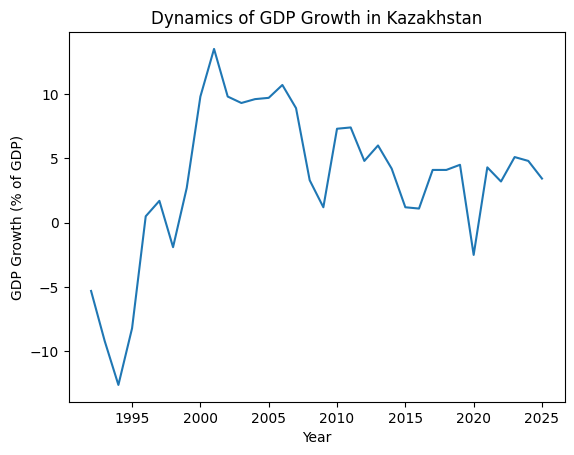

In [11]:
plt.figure()
plt.plot(df["Date"], df["GDP Growth"])
plt.xlabel("Year")
plt.ylabel("GDP Growth (% of GDP)")
plt.title("Dynamics of GDP Growth in Kazakhstan")

### 6. Выберите объясняющую переменную, отвечающую за работу фискального правила. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранной переменной, опишите ее. Приведите ссылку на статистический источник.

In [12]:
df["Oil Prices"].describe().round(3)

count     34.000
mean      66.891
std       23.623
min       24.460
25%       54.232
50%       66.890
75%       77.818
max      111.570
Name: Oil Prices, dtype: float64

Text(0.5, 1.0, 'Dynamics of Oil Prices in Kazakhstan')

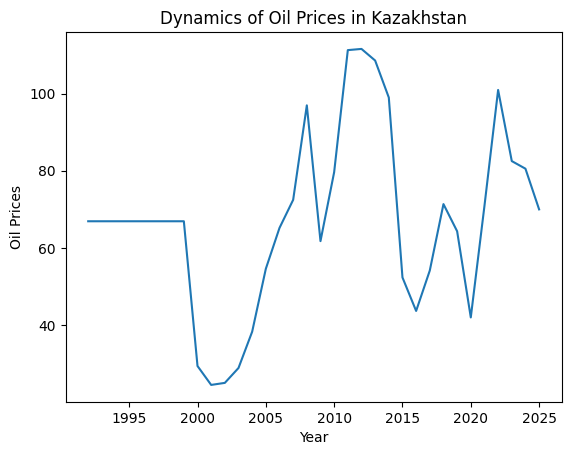

In [13]:
plt.figure()
plt.plot(df["Date"], df["Oil Prices"])
plt.xlabel("Year")
plt.ylabel("Oil Prices")
plt.title("Dynamics of Oil Prices in Kazakhstan")

### 7. Выберите контрольные переменные для Вашего исследования. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранных переменных, опишите ее. Приведите ссылки на статистические источники.

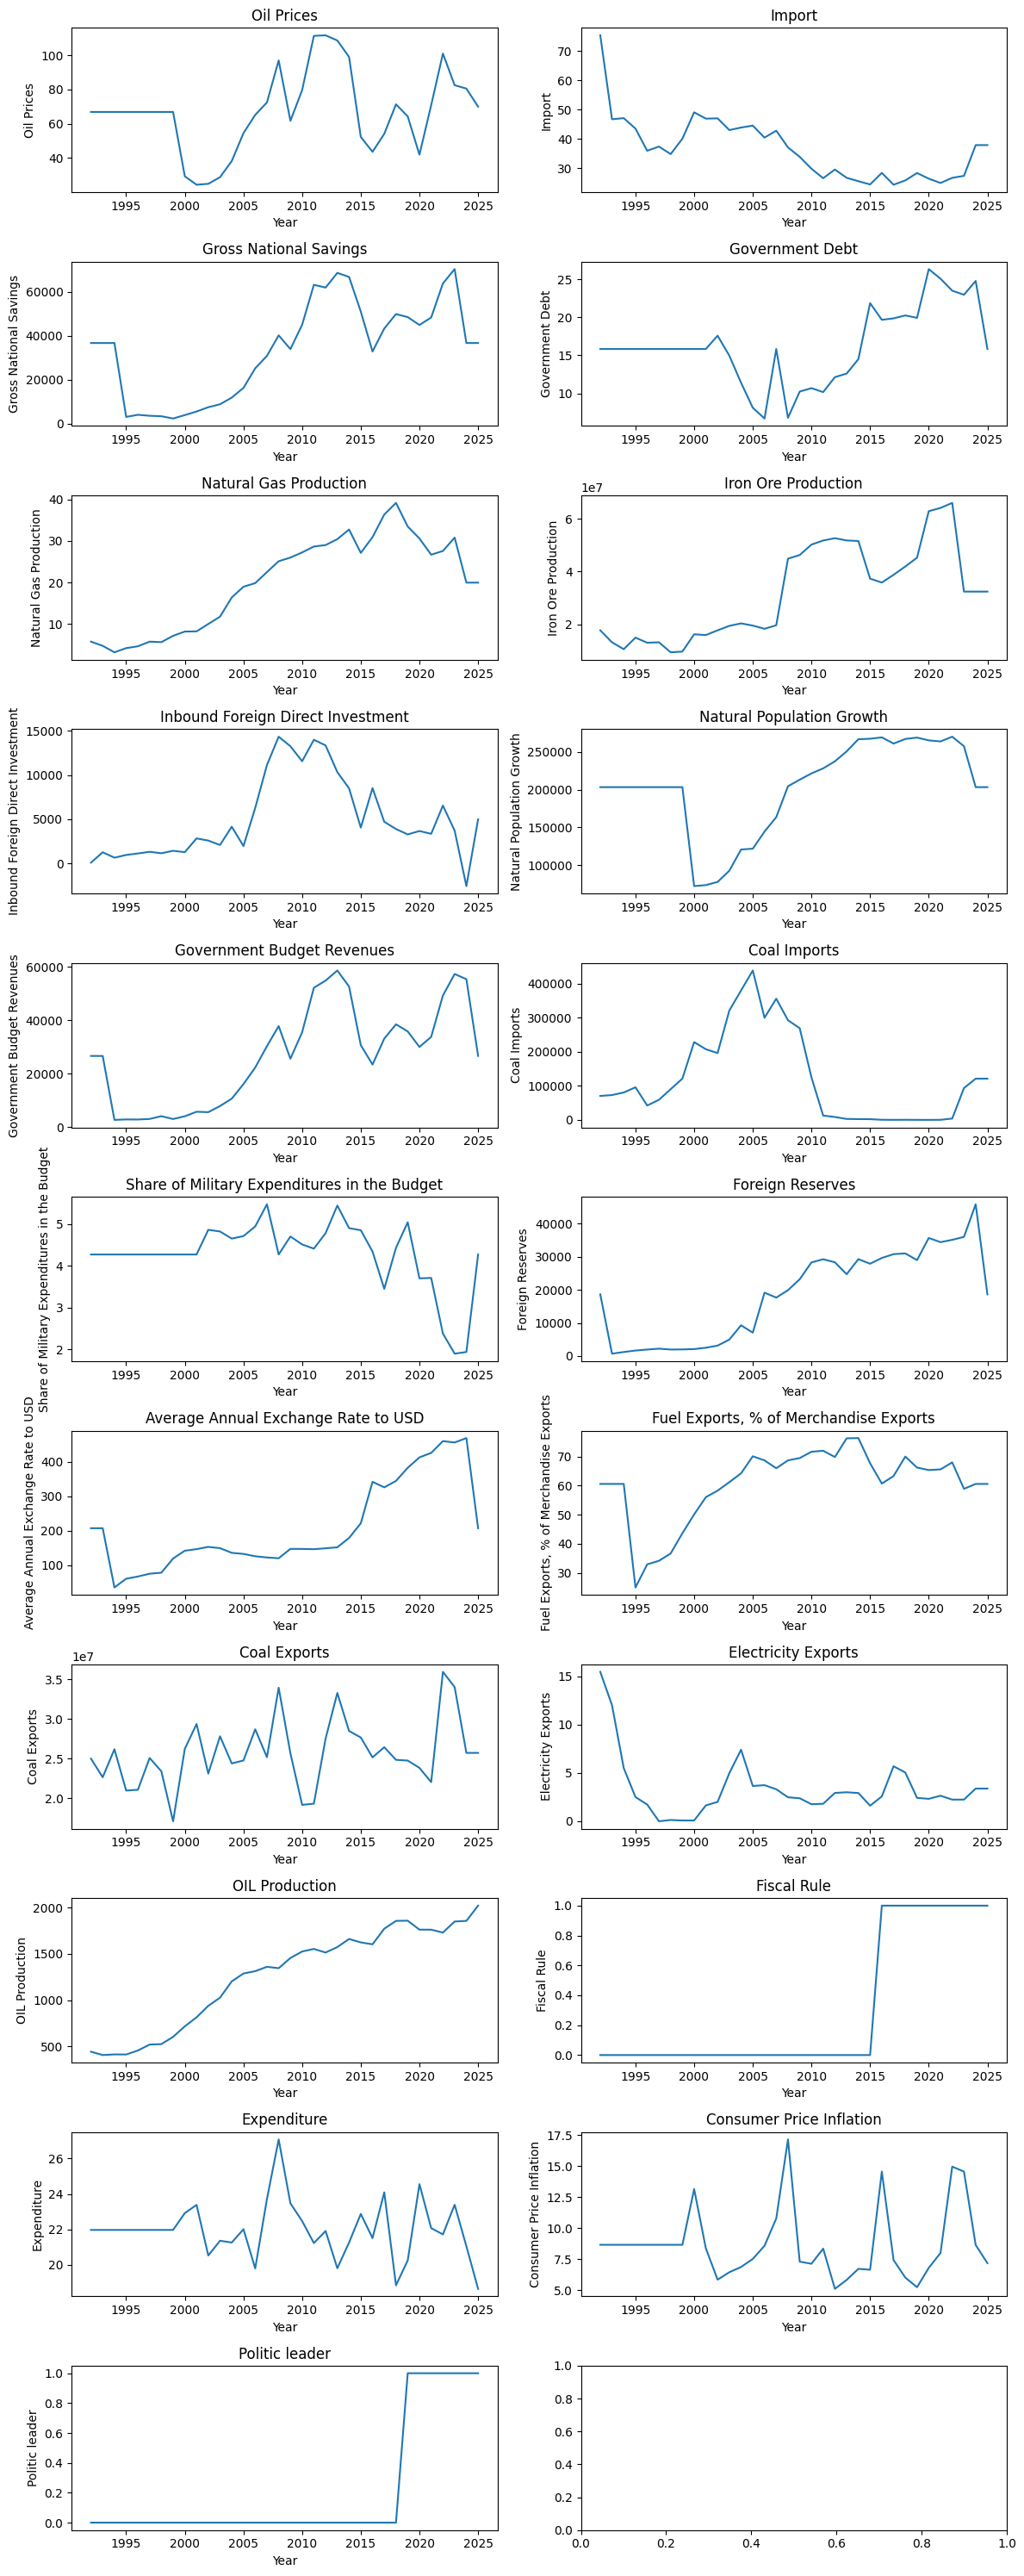

In [14]:
vars_to_plot = [
    'Oil Prices',                 # контрольная
    'Import',
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Fiscal Rule',
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader'
]

fig, axes = plt.subplots(11, 2, figsize=(12, 30))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    axes[i].plot(df["Date"], df[var])
    axes[i].set_title(var)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel(var)

plt.tight_layout()

### 8. Если Вы используете дамми-переменную в своем исследовании, опишите и обоснуйте.

### 9. Выпишите уравнение спецификации, которое Вы будете оценивать. В таблице опишите все основные описательные статистики выбранных переменных.

In [15]:
df.describe().round(2)

,Date,Import,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
count,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00
mean,2008.50,36.53,33569.52,16.18,19.97,31936761.76,4994.21,203480.54,26573.71,120972.59,4.27,18604.72,3.43,207.42,60.61,25723621.19,3.38,1257.72,66.89,0.29,21.97,8.66,0.21
std,9.96,10.65,22108.82,5.08,11.16,17705090.54,4545.76,61390.31,18631.01,129956.72,0.82,13623.14,5.89,128.28,12.54,4220621.13,3.11,533.55,23.62,0.46,1.62,2.93,0.41
min,1992.00,24.43,2313.00,6.68,3.18,9335800.00,-2550.49,72276.00,2637.00,21.00,1.90,711.00,-12.60,35.54,24.99,17097980.00,0.00,408.00,24.46,0.00,18.65,5.11,0.00
25%,2000.25,26.96,9553.25,13.08,8.19,16535350.00,1350.86,203480.54,6216.50,3113.50,4.27,2664.75,1.20,127.79,59.35,23510567.50,1.86,742.25,54.23,0.00,21.26,6.82,0.00
50%,2008.50,36.58,36673.91,15.84,21.24,32363100.00,3691.76,203480.54,26573.71,85266.00,4.27,19505.00,4.15,149.35,63.80,25170530.50,2.54,1407.50,66.89,0.00,21.97,8.36,0.00
75%,2016.75,43.42,48426.50,19.82,28.93,45991475.00,8002.58,260375.25,37255.25,204502.50,4.76,29241.25,7.38,299.93,68.72,27631718.00,3.58,1712.07,77.82,1.00,22.77,8.66,0.00
max,2025.00,75.33,70302.00,26.36,39.18,66000000.00,14321.76,270370.00,58577.00,438410.00,5.47,45808.00,13.50,468.96,76.39,35948140.00,15.45,2019.86,111.57,1.00,27.07,17.15,1.00


### 10.  Используя МНК, эмпирически оцените коэффициенты Вашей модели. Результаты оценки представьте в тексте в адекватном и аккуратном виде. Вы обязаны скопировать результаты из используемой программы в Приложение! Без этого работа оценивается как 0. Проинтерпретируйте полученные результаты.

 # Как варик брать не все-все переменные, а с самой большой корреляцыей по модулю

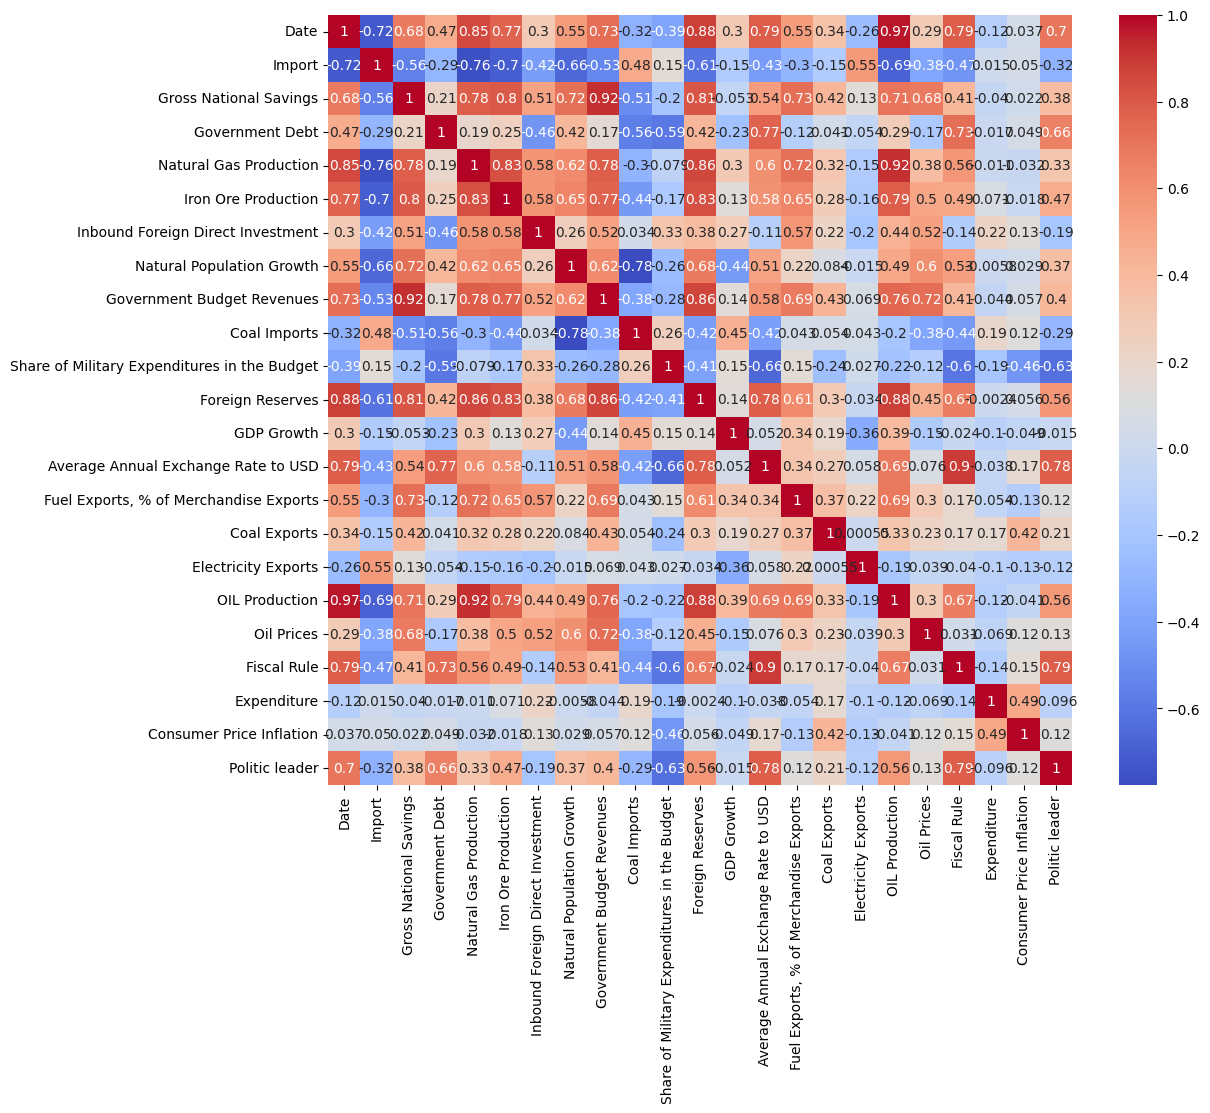

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [17]:
import pandas as pd

# Предположим, df - ваш DataFrame
# Удаляем столбец 'Date'
df_without_date = df.drop(columns=['Date'])

# Рассчитываем корреляцию для оставшихся столбцов
corr = df_without_date.corr(numeric_only=True)

target = "Government Debt"  # или любой другой столбец

# Получаем 8 столбцов с наибольшей абсолютной корреляцией с целевым столбцом
top8 = corr[target].abs().sort_values(ascending=False).iloc[1:9]
top8

Average Annual Exchange Rate to USD             0.765166
Fiscal Rule                                     0.728419
Politic leader                                  0.657309
Share of Military Expenditures in the Budget    0.589387
Coal Imports                                    0.564469
Inbound Foreign Direct Investment               0.464280
Foreign Reserves                                0.418898
Natural Population Growth                       0.416598
Name: Government Debt, dtype: float64

In [18]:
vars_selected = [
    "Average Annual Exchange Rate to USD",
    "Fiscal Rule",
    "Politic leader",
    "Share of Military Expenditures in the Budget",
    "Coal Imports",
    "Inbound Foreign Direct Investment",
    "Foreign Reserves",
    "Natural Population Growth"
]

y = df["GDP Growth"]

X = df[vars_selected]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             GDP Growth   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     5.878
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           0.000286
Time:                        09:27:13   Log-Likelihood:                -90.020
No. Observations:                  34   AIC:                             198.0
Df Residuals:                      25   BIC:                             211.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                           10.0333      8.239      1.218      0.235      -6.934      27.001
Average Annual Exchange Rate to USD              0.0066      0.018      0.366      0.717      -0.030       0.044
Fiscal Rule                                      2.4809      3.723      0.666      0.511      -5.187      10.148
Politic leader                                  -0.6831      2.987     -0.229      0.821      -6.834       5.468
Share of Military Expenditures in the Budget     1.5186      1.226      1.239      0.227      -1.005       4.043
Coal Imports                                 -3.493e-06   9.34e-06     -0.374      0.712   -2.27e-05    1.58e-05
Inbound Foreign Direct Investment                0.0004      0.000      1.549      0.134      -0.000       0.001
Foreign Reserves                                 0.0003      0.000      1.912      0.067   -2.03e-05       0.001
Natural Population Growth                       -0.0001   2.43e-05     -4.346      0.000      -0.000   -5.55e-05
==============================================================================
Omnibus:                        2.259   Durbin-Watson:                   1.179
Prob(Omnibus):                  0.323   Jarque-Bera (JB):                1.966
Skew:                          -0.570   Prob(JB):                        0.374
Kurtosis:                       2.702   Cond. No.                     2.95e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.95e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [19]:
model.params.round(5)

const                                           10.03327
Average Annual Exchange Rate to USD              0.00659
Fiscal Rule                                      2.48085
Politic leader                                  -0.68309
Share of Military Expenditures in the Budget     1.51862
Coal Imports                                    -0.00000
Inbound Foreign Direct Investment                0.00039
Foreign Reserves                                 0.00026
Natural Population Growth                       -0.00011
dtype: float64

In [20]:
p = model.pvalues

significant = [var for var in p.index if p[var] < 0.10]
nonsignificant = [var for var in p.index if p[var] >= 0.10]

print("Значимые переменные:", significant)
print("Незначимые переменные:", nonsignificant)


Значимые переменные: ['Foreign Reserves', 'Natural Population Growth']
Незначимые переменные: ['const', 'Average Annual Exchange Rate to USD', 'Fiscal Rule', 'Politic leader', 'Share of Military Expenditures in the Budget', 'Coal Imports', 'Inbound Foreign Direct Investment']


также, построим 95% доверительные интервалы для всех коэффициентов:

In [21]:
conf = model.conf_int(alpha=0.05)

significant_ci = []
nonsignificant_ci = []

for var in conf.index:
    low, high = conf.loc[var]
    if low > 0 or high < 0:      # интервал не содержит ноль
        significant_ci.append(var)
    else:
        nonsignificant_ci.append(var)

print("Значимые по доверительным интервалам:", significant_ci)
print("Незначимые по доверительным интервалам:", nonsignificant_ci)

Значимые по доверительным интервалам: ['Natural Population Growth']
Незначимые по доверительным интервалам: ['const', 'Average Annual Exchange Rate to USD', 'Fiscal Rule', 'Politic leader', 'Share of Military Expenditures in the Budget', 'Coal Imports', 'Inbound Foreign Direct Investment', 'Foreign Reserves']


### 11.  Проведите проверку результатов на устойчивость. Метод Вы выбираете сами. Устойчивы ли Ваши результаты?

#### 1 способ: Робастные стандартные ошибки (HC3)

In [22]:
model_robust = model.get_robustcov_results(cov_type="HC3")

p = model_robust.pvalues
names = model_robust.model.exog_names

significant = [names[i] for i in range(len(p)) if p[i] < 0.10]
nonsignificant = [names[i] for i in range(len(p)) if p[i] >= 0.10]

print("Значимые (robust):", significant)
print("Незначимые (robust):", nonsignificant)

Значимые (robust): ['Natural Population Growth']
Незначимые (robust): ['const', 'Average Annual Exchange Rate to USD', 'Fiscal Rule', 'Politic leader', 'Share of Military Expenditures in the Budget', 'Coal Imports', 'Inbound Foreign Direct Investment', 'Foreign Reserves']


#### 2 способ: Мультиколлинеарность (VIF)

In [23]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,Variable,VIF
0,const,145.347485
1,Average Annual Exchange Rate to USD,11.059889
2,Fiscal Rule,6.161895
3,Politic leader,3.122967
4,Share of Military Expenditures in the Budget,2.086157
5,Coal Imports,3.064910
6,Inbound Foreign Direct Investment,2.683485
7,Foreign Reserves,7.319740
8,Natural Population Growth,4.611049


#### 3 способ: оценка модели на части признаков. (Leave-one-out robustness check)

Мы проверяем, насколько чувствительны результаты модели к выбору набора регрессоров. Для этого по очереди исключаем из модели каждую объясняющую переменную, заново оцениваем регрессию и смотрим, как изменяется коэффициент при ключевой переменной FiscalRule. Если коэффициент остаётся примерно таким же, значит модель устойчива к спецификации; если изменяется резко, значит зависимость чувствительна к исключению этой переменной.

Этот метод широко используется как тест устойчивости результатов (robustness to model specification).

In [24]:
y = df["GDP Growth"]

control_vars = [
    'Import',
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader'
]

results = []

for var in control_vars:
    vars_subset = [v for v in control_vars if v != var]
    model = sm.OLS(y, sm.add_constant(df[vars_subset + ["Oil Prices"]])).fit()
    coef = model.params.get("Oil Prices", None)
    results.append([var, coef])

pd.DataFrame(results, columns=["Removed variable", "OilPrices coefficient"])

,Removed variable,OilPrices coefficient
0,Import,0.165735
1,Gross National Savings,0.165379
2,Government Debt,0.147213
3,Natural Gas Production,0.178201
4,Iron Ore Production,0.142880
5,Inbound Foreign Direct Investment,0.171483
6,Natural Population Growth,-0.097154
7,Government Budget Revenues,0.106581
8,Coal Imports,0.155317
9,Share of Military Expenditures in the Budget,0.090085


### 12.  Постройте прогноз, используя Вашу оцененную модель. Результаты представьте на графике. Опишите его и проинтерпретируйте.

прогноз по 3-летнему скользящему среднему (MA-3) и подстановка результата OLS-модель.

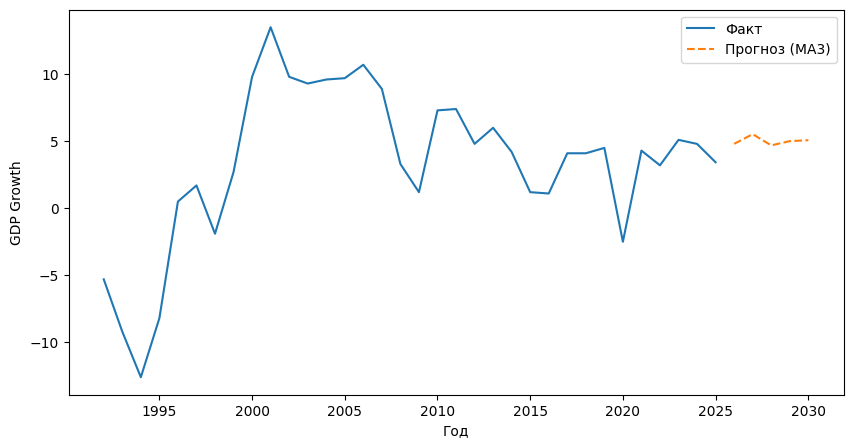

In [25]:
X_vars = [
    'Import',
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Oil Prices',          
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader',
    'Fiscal Rule'
]

future_years = [2026, 2027, 2028, 2029, 2030]

X_extended = df[X_vars].copy()

for year in future_years:
    ma3 = X_extended.tail(3).mean()
    X_extended.loc[year] = ma3

X_future = X_extended.loc[future_years].copy()
X_future["const"] = 1
X_future = X_future[model.model.exog_names]

forecast_ma = model.predict(X_future)

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["GDP Growth"], label="Факт")
plt.plot(forecast_ma.index, forecast_ma.values, label="Прогноз (MA3)", linestyle="--")
plt.xlabel("Год")
plt.ylabel("GDP Growth")
plt.legend()
plt.show()